# FID Analysis — Real vs Sapien vs Simple

This notebook computes and visualises the **Fréchet Inception Distance (FID)**
between three image distributions:

| Set | Description |
|-----|-------------|
| **Real** | Frames captured from the physical Sphero Bolt environment |
| **Sapien** | Rendered frames from the Sapien physics simulator |
| **Simple** | Rendered frames from the simplified custom renderer |

A lower FID indicates that the distribution of simulated images is closer to
real images — i.e. better visual sim-to-real transfer.

---

## How FID works

FID fits a multivariate Gaussian to the 2048-dimensional pool features of a
pretrained Inception-v3 model for each image set, then computes the squared
Wasserstein-2 distance between the two Gaussians:

$$
\text{FID} = \|\mu_1 - \mu_2\|^2 + \text{Tr}\!\left(\Sigma_1 + \Sigma_2 - 2\sqrt{\Sigma_1 \Sigma_2}\right)
$$

Because 2048-d is not directly visualisable, features are projected onto the
top principal components (PCA) and plotted as:
- **1D** bell curves (PC1 only)
- **2D** ellipses (PC1 + PC2)
- **3D** ellipsoids (PC1 + PC2 + PC3)

PCA is always fitted **once on all three distributions together** so that the
Real curve is identical across both comparison plots.

---

## Two implementations

| | `get_or_compute_features` | `get_or_compute_pytorch_fid_features` |
|---|---|---|
| **Weights** | torchvision ImageNet (`weights='DEFAULT'`) | Original TensorFlow FID weights (`pt_inception-2015-12-05`) |
| **Architecture** | Standard torchvision Inception-v3 | Patched Inception-v3 matching TF pooling behaviour |
| **Normalisation** | `[0, 1]` input, `transform_input=True` | `[0, 1]` input → model scales to `[-1, 1]` internally |
| **Comparability** | Custom / exploratory | ✅ Directly comparable to published FID scores |
| **Cache files** | `feats_*.npy` | `feats_*_pfid.npy` |

> **Use `pytorch-fid` scores for any numbers reported in papers.**
> The torchvision-based scores are useful for relative comparison only.

# Import

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from calc_fid import load_images_from_folder, get_inception_features, compute_fid, plot_gaussian_ellipses, plot_gaussian_1d, plot_gaussian_3d, get_or_compute_features, get_or_compute_pytorch_fid_features

In [15]:
# --- Plot settings ---
figsize   = (8, 4)   # (width, height) in inches
fontsize  = 10         # base font size for labels, legend, annotations

show_1d   = True      # 1-D bell curves (PC1 projection)
show_2d   = False     # 2-D ellipses    (PC1 + PC2)
show_3d   = False     # 3-D ellipsoids  (PC1 + PC2 + PC3)

save_dir  = Path("output")   # set to None to disable saving, or e.g. Path("output/fid_plots")

In [3]:
# --- Path setup ---
real_path   = Path("image_folder/real")
sapien_path = Path("image_folder/sapien")
simple_path = Path("image_folder/simple")

cache_dir = Path("image_folder/feats_cache")

In [4]:
# --- Features (loaded from cache or computed once and saved) ---
feats_real   = get_or_compute_features(real_path,   cache_dir / "feats_real.npy",   batch_size=16, device='cuda')
feats_sapien = get_or_compute_features(sapien_path, cache_dir / "feats_sapien.npy", batch_size=16, device='cuda')
feats_simple = get_or_compute_features(simple_path, cache_dir / "feats_simple.npy", batch_size=16, device='cuda')

print(f"\nFID  Real vs Sapien = {compute_fid(feats_real, feats_sapien):.4f}")
print(f"FID  Real vs Simple = {compute_fid(feats_real, feats_simple):.4f}")

Loaded features ← image_folder\feats_cache\feats_real.npy  (501 vectors)
Loaded features ← image_folder\feats_cache\feats_sapien.npy  (501 vectors)
Loaded features ← image_folder\feats_cache\feats_simple.npy  (501 vectors)

FID  Real vs Sapien = 70.6432
FID  Real vs Simple = 88.7335


# Gaussian distribution visualisation (Wasserstein-2 / Fréchet distance)
The FID score is the squared Wasserstein-2 distance between two multivariate
Gaussians N(μ₁,Σ₁) and N(μ₂,Σ₂) fitted to the Inception feature sets.
Because the feature space is 2048-d, we project onto the top-2 principal
components (PCA) and draw the 2σ ellipses of both distributions.
  FID = ||μ₁ − μ₂||² + Tr(Σ₁ + Σ₂ − 2·sqrtm(Σ₁·Σ₂))
        ↑ mean-shift (arrow)    ↑ covariance term (ellipse shapes)

In [5]:
from sklearn.decomposition import PCA
import numpy as np

# Fit PCA once on all three distributions — keeps the coordinate system
# consistent so the Real curve is identical in both comparison plots.
all_feats = np.concatenate([feats_real, feats_sapien, feats_simple], axis=0)

shared_pca_2d = PCA(n_components=2)
shared_pca_2d.fit(all_feats)

shared_pca_3d = PCA(n_components=3)
shared_pca_3d.fit(all_feats)

shared_pca_1d = PCA(n_components=1)
shared_pca_1d.fit(all_feats)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",1
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

### Sapien

Saved plot → output\real_vs_sapien_1d.pdf


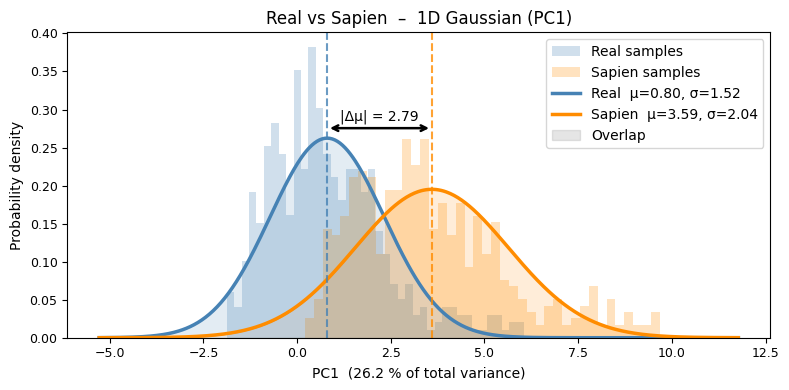

In [16]:
# 1-D Gaussian bell curves (PC1 projection)
# Shows the classic Gauss curve for both distributions on the most
# discriminative axis. Grey overlap = similar; less overlap = higher FID.
# --- Real vs Sapien (1D) ---
if show_1d:
    plot_gaussian_1d(feats_real, feats_sapien,
        title="Real vs Sapien  –  1D Gaussian (PC1)",
        labels=("Real", "Sapien"), colors=("steelblue", "darkorange"), pca=shared_pca_1d,
        figsize=figsize, fontsize=fontsize,
        save_path=save_dir / "real_vs_sapien_1d.pdf" if save_dir else None)

# --- Real vs Sapien (2D) ---
if show_2d:
    plot_gaussian_ellipses(feats_real, feats_sapien, n_std=2.0,
        title="Real vs Sapien  –  2D Gaussian",
        labels=("Real", "Sapien"), colors=("steelblue", "darkorange"), pca=shared_pca_2d,
        figsize=figsize, fontsize=fontsize,
        save_path=save_dir / "real_vs_sapien_2d.pdf" if save_dir else None)

# 3-D scatter + ellipsoid visualisation (PCA 3D projection)
# --- Real vs Sapien (3D) ---
if show_3d:
    plot_gaussian_3d(feats_real, feats_sapien, n_std=2.0,
        title="Real vs Sapien  –  3D Gaussian",
        labels=("Real", "Sapien"), colors=("steelblue", "darkorange"), pca=shared_pca_3d,
        figsize=figsize, fontsize=fontsize,
        save_path=save_dir / "real_vs_sapien_3d.pdf" if save_dir else None)

### Simple

Saved plot → output\real_vs_simple_1d.pdf


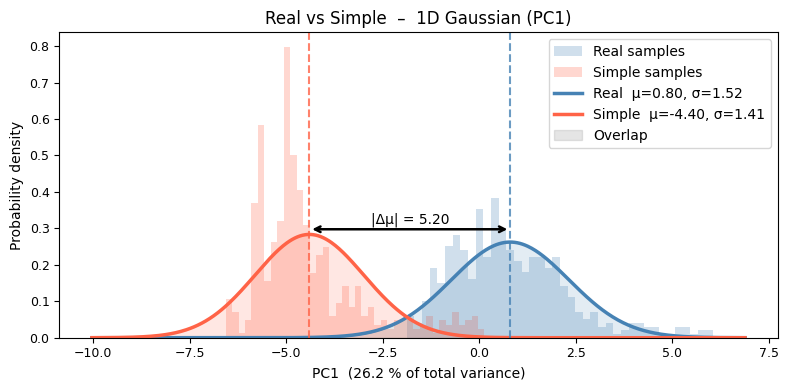

In [17]:
# 1-D Gaussian bell curves (PC1 projection)
# Shows the classic Gauss curve for both distributions on the most
# discriminative axis. Grey overlap = similar; less overlap = higher FID.
# --- Real vs Simple (1D) ---
if show_1d:
    plot_gaussian_1d(feats_real, feats_simple,
        title="Real vs Simple  –  1D Gaussian (PC1)",
        labels=("Real", "Simple"), colors=("steelblue", "tomato"), pca=shared_pca_1d,
        figsize=figsize, fontsize=fontsize,
        save_path=save_dir / "real_vs_simple_1d.pdf" if save_dir else None)

# --- Real vs Simple (2D) ---
if show_2d:
    plot_gaussian_ellipses(feats_real, feats_simple, n_std=2.0,
        title="Real vs Simple  –  2D Gaussian",
        labels=("Real", "Simple"), colors=("steelblue", "tomato"), pca=shared_pca_2d,
        figsize=figsize, fontsize=fontsize,
        save_path=save_dir / "real_vs_simple_2d.pdf" if save_dir else None)

# --- Real vs Simple (3D) ---
if show_3d:
    plot_gaussian_3d(feats_real, feats_simple, n_std=2.0,
        title="Real vs Simple  –  3D Gaussian",
        labels=("Real", "Simple"), colors=("steelblue", "tomato"), pca=shared_pca_3d,
        figsize=figsize, fontsize=fontsize,
        save_path=save_dir / "real_vs_simple_3d.pdf" if save_dir else None)

# pytorch-fid reference scores (original TensorFlow FID weights)
Uses pt_inception-2015-12-05-6726825d.pth — directly comparable to published FID results.
First run downloads ~100 MB weights once; subsequent runs load from .npy cache instantly.

In [8]:
# --- pytorch-fid features (cached separately from torchvision features) ---
pfid_real   = get_or_compute_pytorch_fid_features(real_path,   cache_dir / "feats_real_pfid.npy",   batch_size=16, device='cuda')
pfid_sapien = get_or_compute_pytorch_fid_features(sapien_path, cache_dir / "feats_sapien_pfid.npy", batch_size=16, device='cuda')
pfid_simple = get_or_compute_pytorch_fid_features(simple_path, cache_dir / "feats_simple_pfid.npy", batch_size=16, device='cuda')

print(f"\nFID (pytorch-fid)  Real vs Sapien = {compute_fid(pfid_real, pfid_sapien):.4f}")
print(f"FID (pytorch-fid)  Real vs Simple = {compute_fid(pfid_real, pfid_simple):.4f}")

Loaded features ← image_folder\feats_cache\feats_real_pfid.npy  (501 vectors)
Loaded features ← image_folder\feats_cache\feats_sapien_pfid.npy  (501 vectors)
Loaded features ← image_folder\feats_cache\feats_simple_pfid.npy  (501 vectors)

FID (pytorch-fid)  Real vs Sapien = 194.1227
FID (pytorch-fid)  Real vs Simple = 244.8736


In [9]:
# Fit shared PCA on all three pytorch-fid feature sets
all_pfid = np.concatenate([pfid_real, pfid_sapien, pfid_simple], axis=0)

pfid_pca_1d = PCA(n_components=1); pfid_pca_1d.fit(all_pfid)
pfid_pca_2d = PCA(n_components=2); pfid_pca_2d.fit(all_pfid)
pfid_pca_3d = PCA(n_components=3); pfid_pca_3d.fit(all_pfid)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

### Sapien

Saved plot → output\pfid_real_vs_sapien_1d.pdf


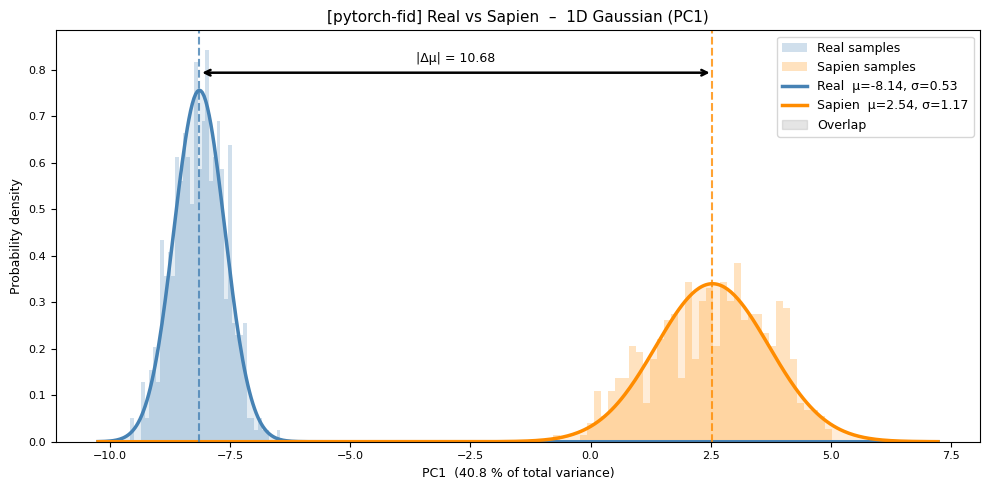

In [10]:
# --- Real vs Sapien (1D) ---
if show_1d:
    plot_gaussian_1d(pfid_real, pfid_sapien,
        title="[pytorch-fid] Real vs Sapien  –  1D Gaussian (PC1)",
        labels=("Real", "Sapien"), colors=("steelblue", "darkorange"), pca=pfid_pca_1d,
        figsize=figsize, fontsize=fontsize,
        save_path=save_dir / "pfid_real_vs_sapien_1d.pdf" if save_dir else None)

# --- Real vs Sapien (2D) ---
if show_2d:
    plot_gaussian_ellipses(pfid_real, pfid_sapien, n_std=2.0,
        title="[pytorch-fid] Real vs Sapien  –  2D Gaussian",
        labels=("Real", "Sapien"), colors=("steelblue", "darkorange"), pca=pfid_pca_2d,
        figsize=figsize, fontsize=fontsize,
        save_path=save_dir / "pfid_real_vs_sapien_2d.pdf" if save_dir else None)

# --- Real vs Sapien (3D) ---
if show_3d:
    plot_gaussian_3d(pfid_real, pfid_sapien, n_std=2.0,
        title="[pytorch-fid] Real vs Sapien  –  3D Gaussian",
        labels=("Real", "Sapien"), colors=("steelblue", "darkorange"), pca=pfid_pca_3d,
        figsize=figsize, fontsize=fontsize,
        save_path=save_dir / "pfid_real_vs_sapien_3d.pdf" if save_dir else None)

### Simple

Saved plot → output\pfid_real_vs_simple_1d.pdf


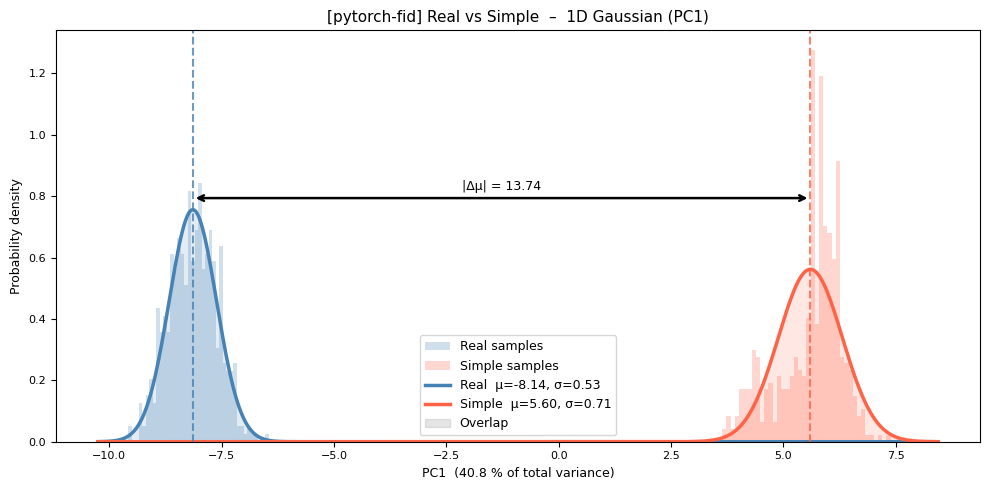

In [11]:
# --- Real vs Simple (1D) ---
if show_1d:
    plot_gaussian_1d(pfid_real, pfid_simple,
        title="[pytorch-fid] Real vs Simple  –  1D Gaussian (PC1)",
        labels=("Real", "Simple"), colors=("steelblue", "tomato"), pca=pfid_pca_1d,
        figsize=figsize, fontsize=fontsize,
        save_path=save_dir / "pfid_real_vs_simple_1d.pdf" if save_dir else None)

# --- Real vs Simple (2D) ---
if show_2d:
    plot_gaussian_ellipses(pfid_real, pfid_simple, n_std=2.0,
        title="[pytorch-fid] Real vs Simple  –  2D Gaussian",
        labels=("Real", "Simple"), colors=("steelblue", "tomato"), pca=pfid_pca_2d,
        figsize=figsize, fontsize=fontsize,
        save_path=save_dir / "pfid_real_vs_simple_2d.pdf" if save_dir else None)

# --- Real vs Simple (3D) ---
if show_3d:
    plot_gaussian_3d(pfid_real, pfid_simple, n_std=2.0,
        title="[pytorch-fid] Real vs Simple  –  3D Gaussian",
        labels=("Real", "Simple"), colors=("steelblue", "tomato"), pca=pfid_pca_3d,
        figsize=figsize, fontsize=fontsize,
        save_path=save_dir / "pfid_real_vs_simple_3d.pdf" if save_dir else None)